# Segment Processing and Randomization

For the pulse data, each pulse is 120 seconds long, which makes segmenting the pulses for training and testing a model really easy. For our partial charge data, we have to do some data processing first. For example, here is a high level picture of one of our partial charge sequences:

In [51]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_

Text(0, 0.5, 'Voltage (V)')

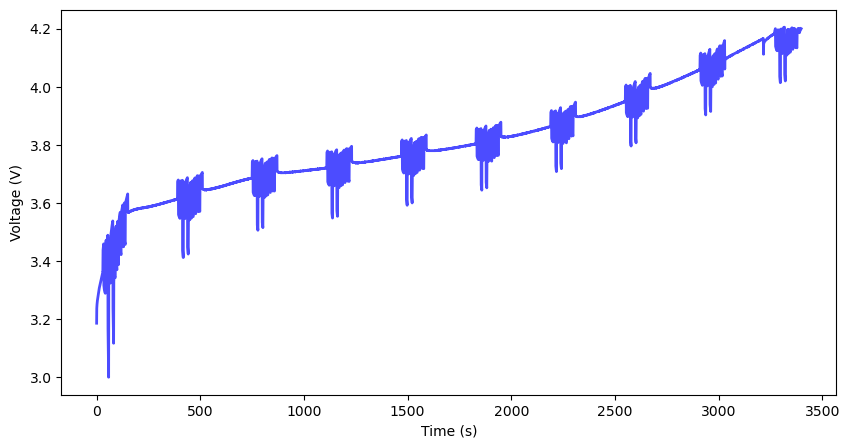

In [52]:
hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
df = hdf.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')
df = df[["PsRP 1 1C diagnostic cycle charge" in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
df = retime(df)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['Segment Time, S'], df['Voltage, V'], label='Raw Data', color='blue', alpha=0.7, linewidth=2)   

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

This looks like fine data, but for proper segmenting, we need each data point to be at consistent one second intervals. Zooming in, we see that is not the case.

Text(0, 0.5, 'Voltage (V)')

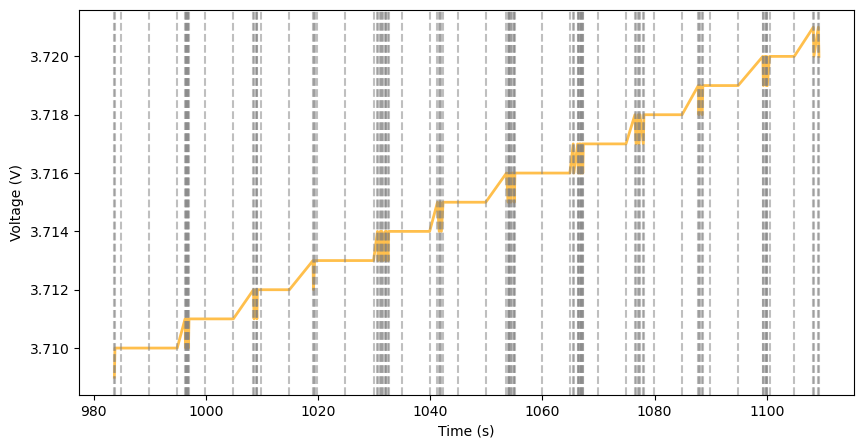

In [53]:
offset = 1000
length = 100
_time = df['Segment Time, S'].iloc[offset:offset+length]
_data = df['Voltage, V'].iloc[offset:offset+length]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(_time, _data, label='Zoomed In', color='orange', alpha=0.7, linewidth=2)
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')


Not only are the data points not sampled evenly, the data points have consistent 5 sec intervals, interspersed with a handful of measurements crammed into a one second space. We need to resample this with some sort of interpolation, the simplest of which is just taking the closest existing measurement at one second intervals. Here is some sample interpolation methods:

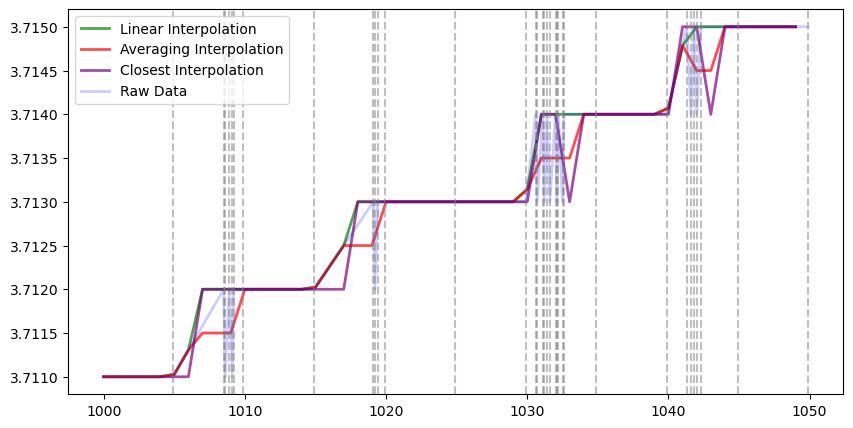

In [54]:
#read from csv, see partial_curves.ipynb for generation
df_out = pd.read_csv('df_out.csv', index_col=0)
df_out_av = pd.read_csv('df_out_av.csv', index_col=0)
df_out_closest = pd.read_csv('df_out_closest.csv', index_col=0)

offset = 1000
length = 50
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_out.iloc[-1][offset:offset+length], df_out.iloc[1][offset:offset+length], label='Linear Interpolation', color='green', alpha=0.7, linewidth=2)
ax.plot(df_out_av.iloc[-1][offset:offset+length], df_out_av.iloc[1][offset:offset+length], label='Averaging Interpolation', color='red', alpha=0.7, linewidth=2)
ax.plot(df_out_closest.iloc[-1][offset:offset+length], df_out_closest.iloc[1][offset:offset+length], label='Closest Interpolation', color='purple', alpha=0.7, linewidth=2)

_time = df[df['Segment Time, S'].between(offset, offset+length)]['Segment Time, S']
_data = df[df['Segment Time, S'].between(offset, offset+length)]['Voltage, V']
ax.plot(_time, _data, label='Raw Data', color='blue', alpha=0.2, linewidth=2)
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.legend()

Ulitmately the precise method is not critical, because the important pulse data is already at 1 second intervals. As long as that data remains unaffected, it will probably be fine.

Next, we have to randomize and segment the data based on what we plan to compare the pulse data to. For example, the 1C cycle is 60 mins long, and we pulse the battery every 6 mins, so if we sample at 8 min long segments, we will always have at least one pulse in the data. 

Found segment starting at 1922 seconds
Found segment starting at 2414 seconds
Found segment starting at 690 seconds
Found segment starting at 199 seconds
Found segment starting at 300 seconds
Found segment starting at 190 seconds
Found segment starting at 2201 seconds
Found segment starting at 377 seconds
Found segment starting at 297 seconds


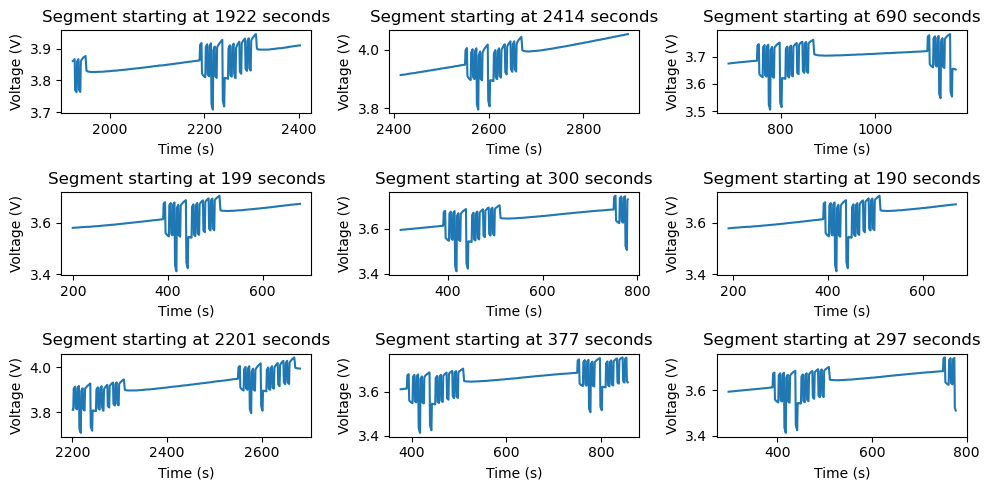

In [58]:
import random
segment_length = 480 # 8 minutes in secs
df = df_out_av.T
# print(df)

fig, ax = plt.subplots(3, 3, figsize=(10, 5))
ax = ax.flatten()
for i in range(9):
    start_time = random.randint(0, 3600 - segment_length)

    df_segment = df[df["Segment_Time_S_A_Cell15_15C"].between(start_time, start_time + segment_length)].T
    # print(len(df_segment.columns), segment_length+1)
    if len(df_segment.columns) == segment_length+1 :
        print(f"Found segment starting at {start_time} seconds")
        ax[i].plot(df_segment.iloc[-1], df_segment.iloc[1])

        ax[i].set_title(f'Segment starting at {start_time} seconds')
        ax[i].set_xlabel('Time (s)')
        ax[i].set_ylabel('Voltage (V)')
    else:
        print(f"Segment starting at {start_time} seconds is incomplete, only {len(df_segment.columns)} data points")

fig.tight_layout()